In [1]:
import torch

data = torch.load("dim2d_nx256_N50_solver=exponax_nu0.000_t20.0_test_forcingPatternnone.pt",weights_only=False)

In [3]:
data["y"].shape

torch.Size([50, 256, 256, 21])

In [4]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

def plot_sample_heatmaps(
    data: torch.Tensor,
    sample_idx: int,
    shared_scale: bool = True,     # True=所有子图共享 vmin/vmax；False=各自独立
    cmap: str = "viridis",
    figsize=(12, 12),
    per_ax_colorbar: bool = False, # 仅在 shared_scale=False 时可考虑每图一个小色条
    titles=None,                   # 可选：长度为21的标题列表
    savepath: str = None,          # 可选：保存路径
):
    """
    data: torch.Tensor, 形状 (50, 256, 256, 21)
    sample_idx: 要选的样本索引 [0..49]
    shared_scale: True=统一色阶；False=各自色阶
    cmap: colormap 名称
    figsize: 画布大小
    per_ax_colorbar: 在各自色阶时，是否每个子图都画自己的色条（多的话会比较拥挤）
    titles: 可选的每通道标题列表（长度应为21）
    savepath: 若提供，则保存图片到该路径
    """
    assert isinstance(data, torch.Tensor), "data 必须是 torch.Tensor"
    assert data.ndim == 4 and data.shape[0] == 50 and data.shape[-1] == 21, \
        f"期望 data 形状为 (50, H, W, 21)，但拿到 {tuple(data.shape)}"
    B, H, W, C = data.shape
    assert 0 <= sample_idx < B, f"sample_idx 必须在 [0, {B-1}]"

    # 取出指定样本 (H, W, 21)
    sample = data[sample_idx]                # torch.Tensor
    sample_np = sample.detach().cpu().numpy()  # 转 numpy，便于 matplotlib

    # 计算统一色阶（如选择 shared_scale=True）
    if shared_scale:
        vmin = float(np.nanmin(sample_np))
        vmax = float(np.nanmax(sample_np))
        # 防止 vmin==vmax
        if vmin == vmax:
            vmin, vmax = vmin - 1e-6, vmax + 1e-6
        norm = Normalize(vmin=vmin, vmax=vmax)
    else:
        norm = None  # 每张子图单独计算

    nrows, ncols = 5, 5
    total_slots = nrows * ncols  # 25
    assert C <= total_slots, "通道数 21 不应超过 5x5 的格子数 25"

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.asarray(axes).reshape(nrows, ncols)

    # 逐通道画图
    for c in range(C):
        r, col = divmod(c, ncols)
        ax = axes[r, col]
        img = sample_np[..., c]
        if shared_scale:
            im = ax.imshow(img, cmap=cmap, norm=norm, origin="lower", aspect="equal")
        else:
            # 各自色阶
            vmin = float(np.nanmin(img))
            vmax = float(np.nanmax(img))
            if vmin == vmax:
                vmin, vmax = vmin - 1e-6, vmax + 1e-6
            im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, origin="lower", aspect="equal")
            if per_ax_colorbar:
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax.set_xticks([])
        ax.set_yticks([])
        if titles is not None and c < len(titles):
            ax.set_title(str(titles[c]), fontsize=10)
        else:
            ax.set_title(f"ch {c}", fontsize=10)

    # 把多出来的 4 个空位关掉坐标轴
    for k in range(C, total_slots):
        r, col = divmod(k, ncols)
        axes[r, col].axis("off")

    # 若使用统一色阶，添加一个全局 colorbar
    if shared_scale:
        cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # 手动加一个竖向色条区域
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])  # 兼容旧 Matplotlib 的写法
        fig.colorbar(sm, cax=cax)

    plt.tight_layout(rect=[0, 0, 0.90, 1.0] if shared_scale else None)

    if savepath is not None:
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_3997656/1062699872.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1.0] if shared_scale else None)


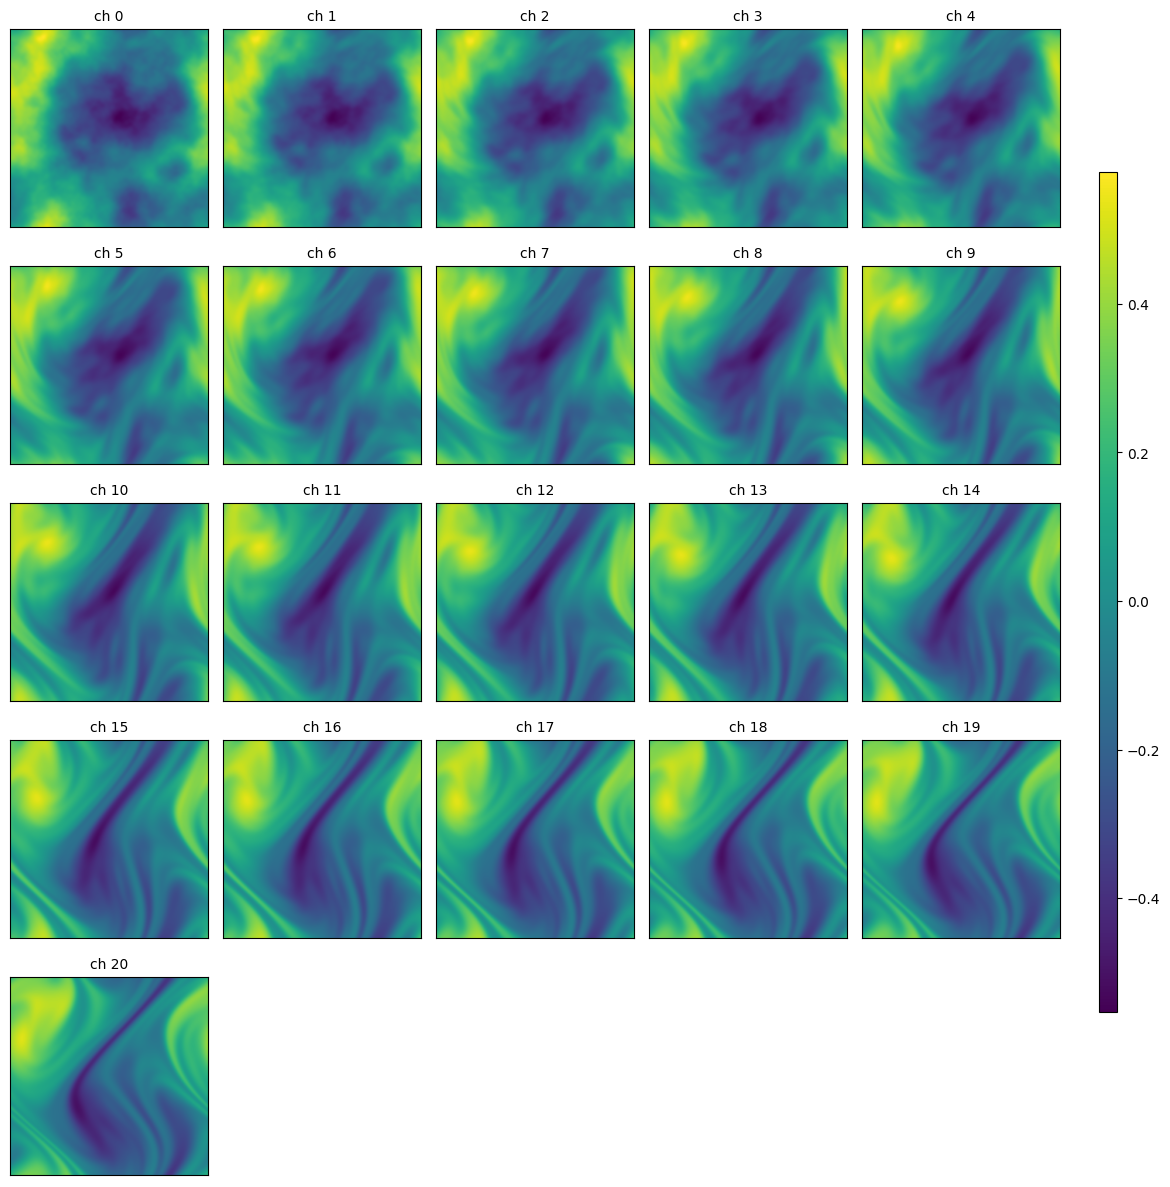

In [5]:
plot_sample_heatmaps(data["y"],
                     sample_idx=0,
                     shared_scale = True)

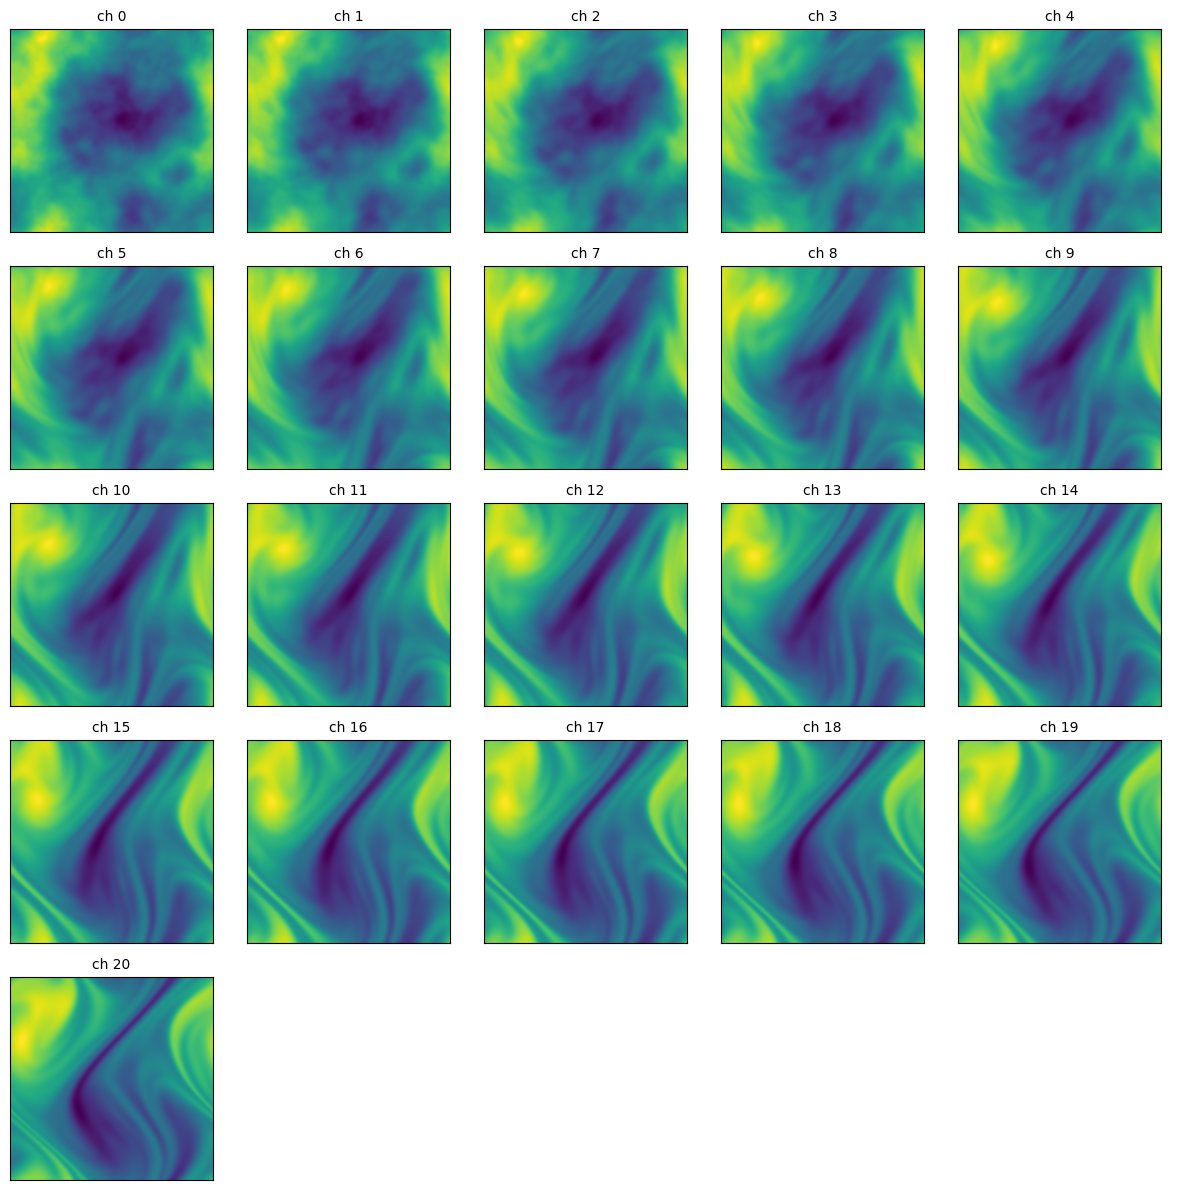

In [6]:
plot_sample_heatmaps(data["y"],
                     sample_idx=0,
                     shared_scale = False)

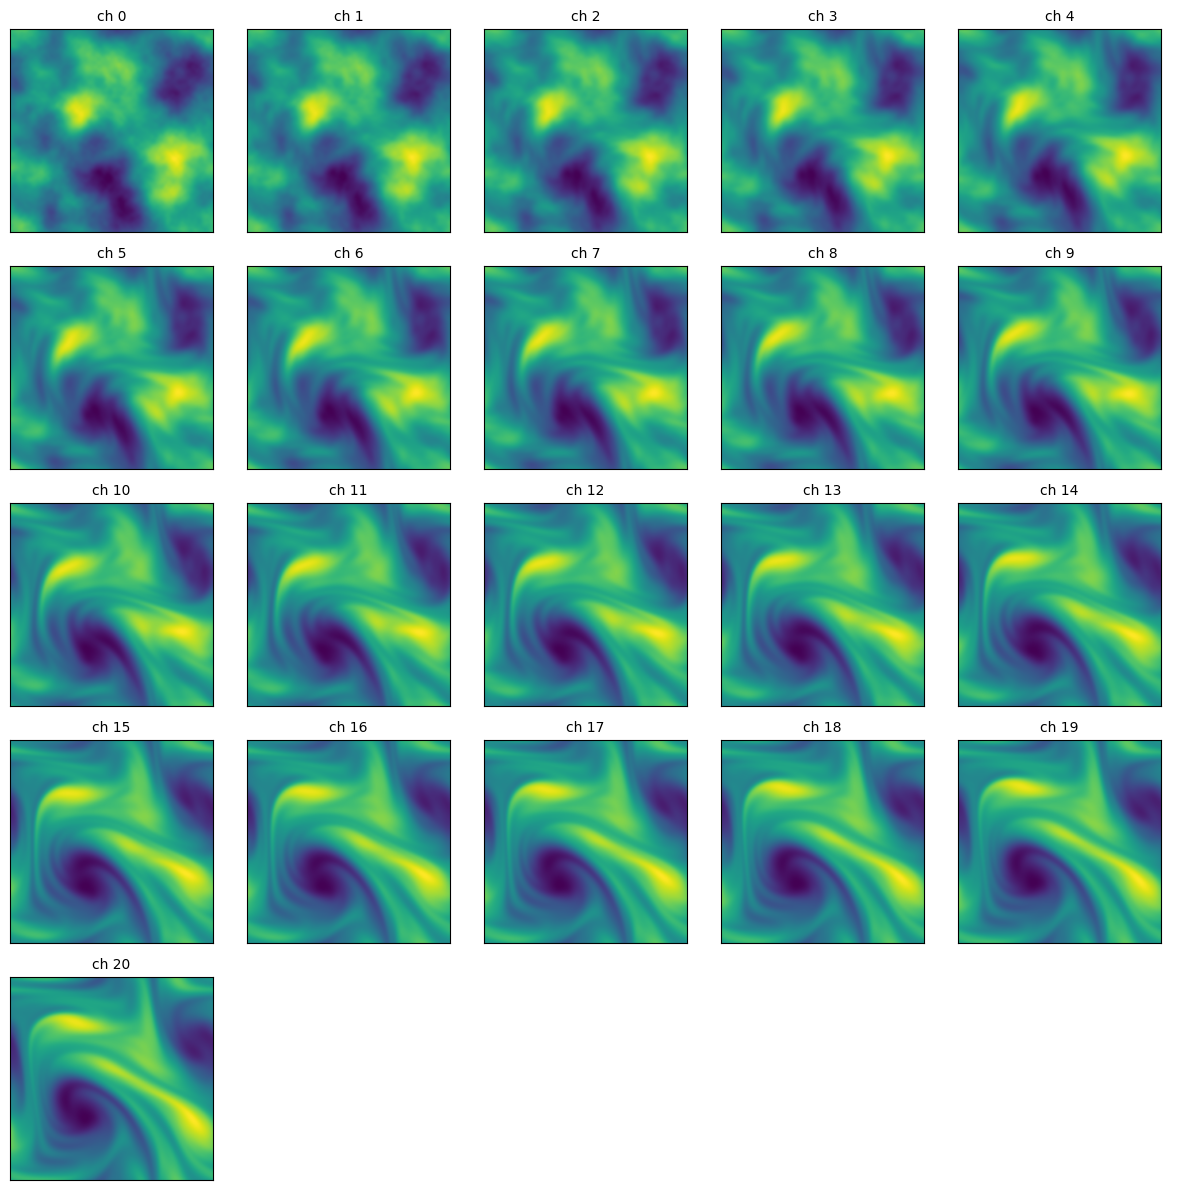

In [7]:
plot_sample_heatmaps(data["y"],
                     sample_idx=1,
                     shared_scale = False)

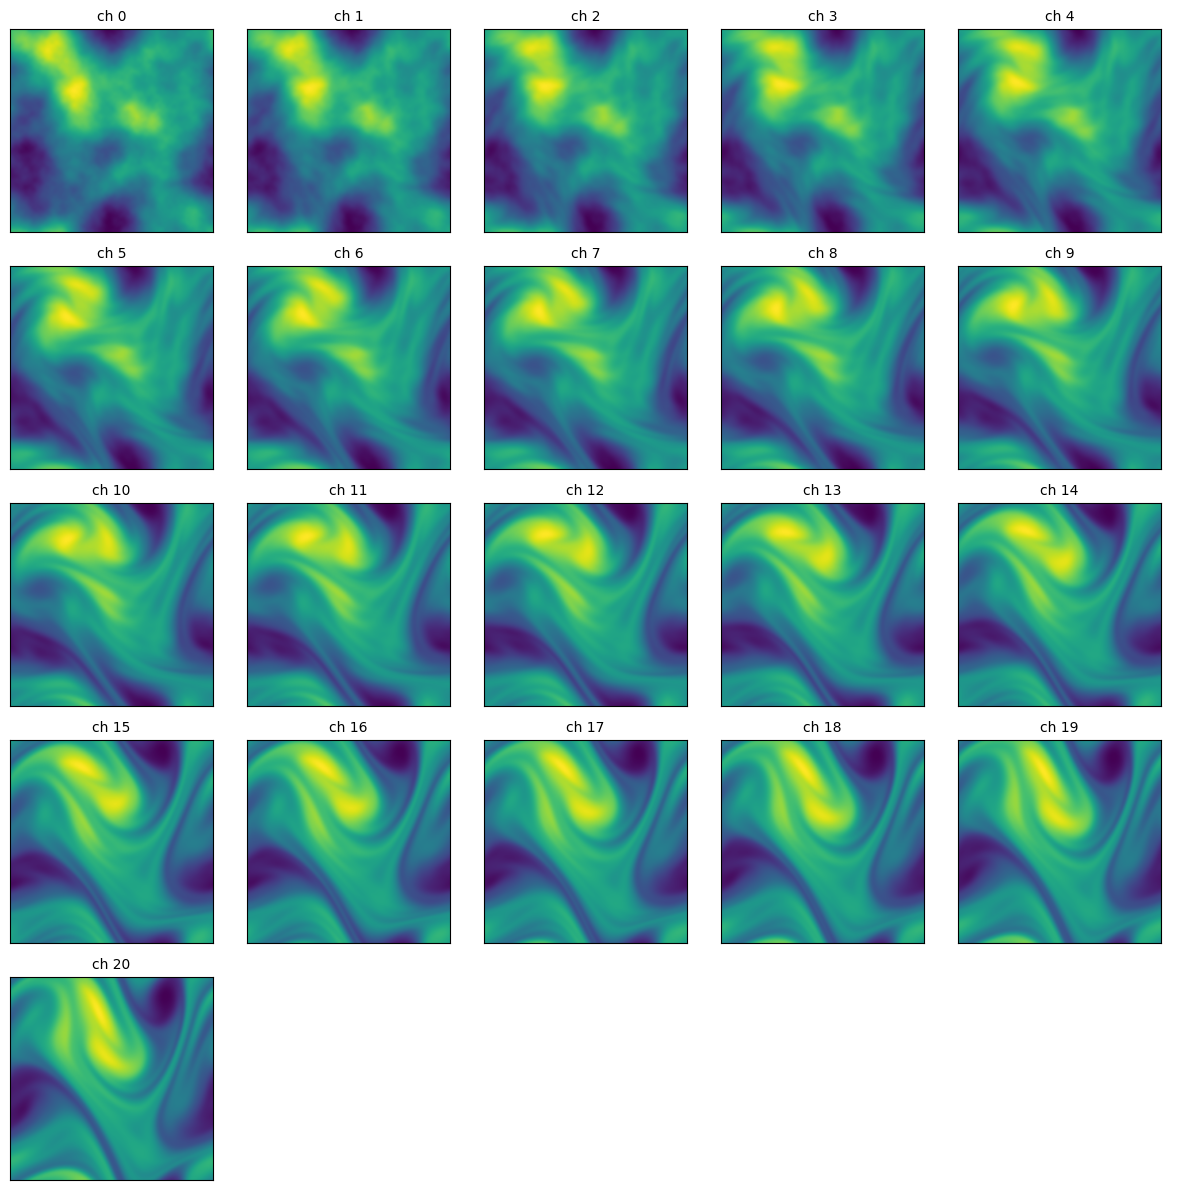

In [8]:
plot_sample_heatmaps(data["y"],
                     sample_idx=2,
                     shared_scale = False)

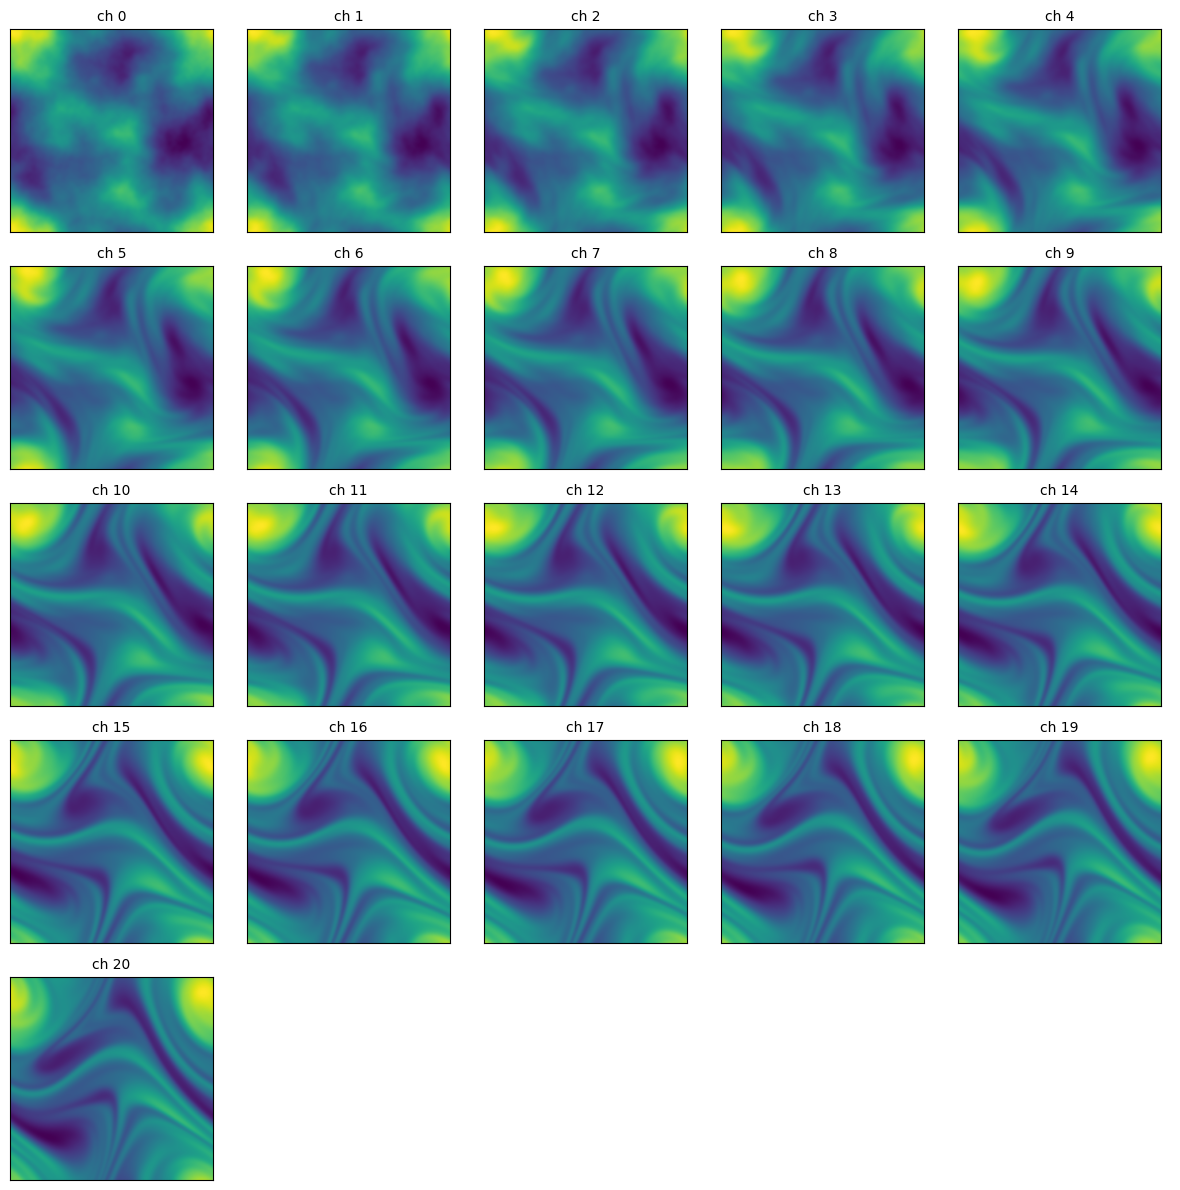

In [9]:
plot_sample_heatmaps(data["y"],
                     sample_idx=3,
                     shared_scale = False)